Task 1: Import Dataset

In [5]:
# Cell 1: Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For display formatting
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [6]:
# Cell 2: Data Loading and Column Selection

try:
    # Load dataset (update path if needed in Colab)
    df = pd.read_csv('/content/tips.csv')


    # Select only required columns
    selected_cols = ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']
    df = df[selected_cols]

    # Basic validation check
    if df.empty:
        raise ValueError("Dataset is empty after column selection.")

    print("Data Loaded Successfully!")
    display(df.head())

except Exception as e:
    print(f"Error loading data: {e}")

Data Loaded Successfully!


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


Task 2: Descriptive Analysis

In [7]:
# Cell 3: Descriptive Analysis for Numerical Columns

try:
    # Select numerical columns
    num_cols = ['total_bill', 'tip', 'size']

    # Initialize empty DataFrame for results
    desc_stats = pd.DataFrame()

    # Calculate required statistics
    desc_stats['Mean'] = df[num_cols].mean()
    desc_stats['Median'] = df[num_cols].median()
    desc_stats['Mode'] = df[num_cols].mode().iloc[0]
    desc_stats['Std Dev'] = df[num_cols].std()
    desc_stats['Min'] = df[num_cols].min()
    desc_stats['Max'] = df[num_cols].max()

    display(desc_stats)

except Exception as e:
    print(f"Error in numerical descriptive analysis: {e}")

,Mean,Median,Mode,Std Dev,Min,Max
total_bill,19.79,17.80,13.42,8.90,3.07,50.81
tip,3.00,2.90,2.00,1.38,1.00,10.00
size,2.57,2.00,2.00,0.95,1.00,6.00


In [8]:
# Cell 4: Descriptive Analysis for Categorical Columns

try:
    cat_cols = ['sex', 'smoker', 'day', 'time']

    cat_summary = {}

    for col in cat_cols:
        cat_summary[col] = {
            'Mode': df[col].mode()[0],
            'Unique Count': df[col].nunique(),
            'Top Frequency': df[col].value_counts().iloc[0]
        }

    cat_summary_df = pd.DataFrame(cat_summary).T
    display(cat_summary_df)

except Exception as e:
    print(f"Error in categorical descriptive analysis: {e}")

,Mode,Unique Count,Top Frequency
sex,Male,2,157
smoker,No,2,151
day,Sat,4,87
time,Dinner,2,176


Task 3: Missing Values Check

In [12]:
# Missing Values Check (Incremental - No Repetition)

try:
    # Compute missing values count and percentage
    missing_count = df.isnull().sum()
    missing_percent = (missing_count / len(df)) * 100

    # Combine into a single DataFrame for better readability
    missing_summary = pd.DataFrame({
        'Missing Count': missing_count,
        'Missing Percentage (%)': missing_percent.round(2)
    })

    print("Missing Values Summary:")
    display(missing_summary)

except Exception as e:
    print("Error during missing value analysis:", str(e))

Missing Values Summary:


,Missing Count,Missing Percentage (%)
total_bill,0,0.00
tip,0,0.00
sex,0,0.00
smoker,0,0.00
day,0,0.00
time,0,0.00
size,0,0.00


Task 4: Outlier Detection

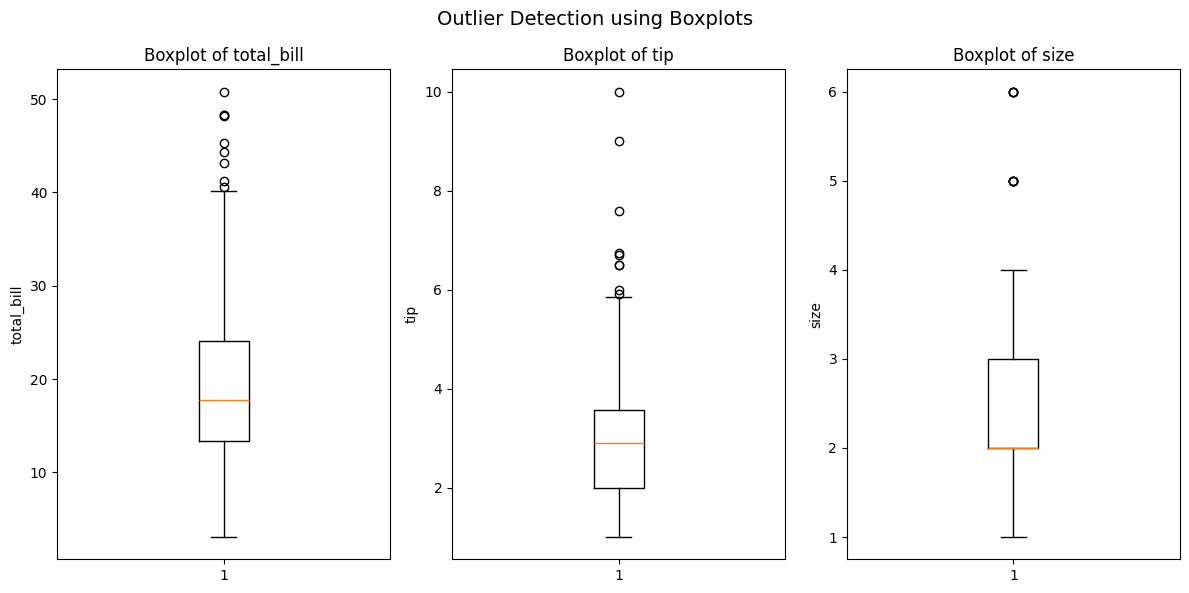

In [15]:
# Cell: Boxplot Visualization for Outlier Detection

try:
    # Select numerical columns only
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns

    # Create boxplots
    plt.figure(figsize=(12, 6))

    for i, col in enumerate(num_cols):
        plt.subplot(1, len(num_cols), i+1)
        plt.boxplot(df[col], vert=True)
        plt.title(f'Boxplot of {col}')
        plt.ylabel(col)

    plt.suptitle('Outlier Detection using Boxplots', fontsize=14)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("Error in boxplot visualization:", str(e))

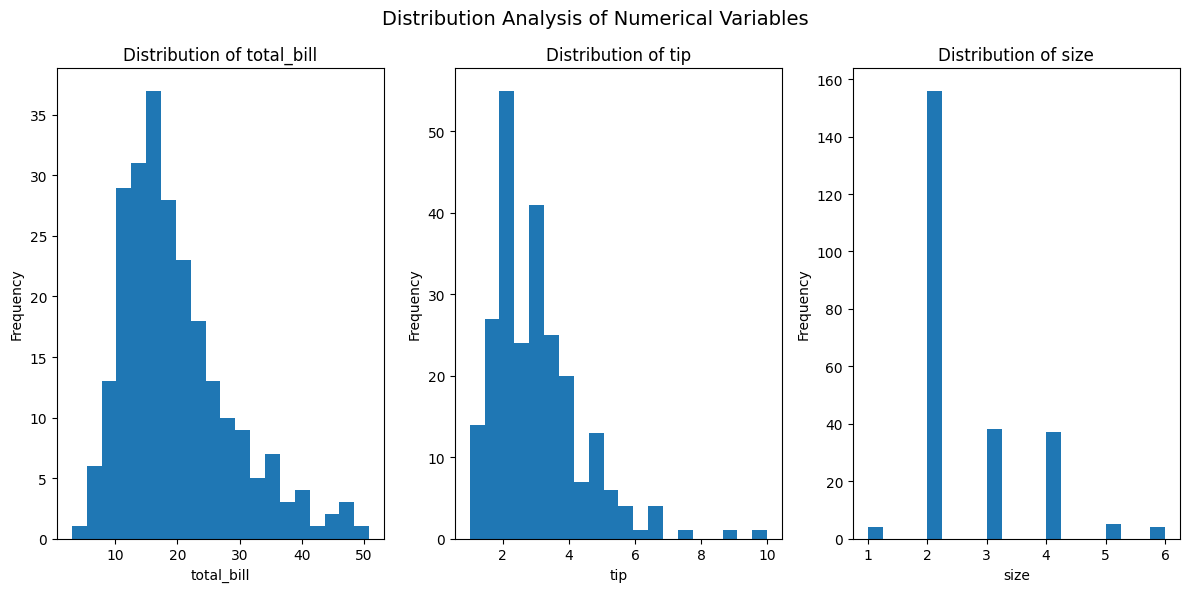

In [16]:
# Cell: Histogram Visualization for Distribution & Outliers

try:
    plt.figure(figsize=(12, 6))

    for i, col in enumerate(num_cols):
        plt.subplot(1, len(num_cols), i+1)
        plt.hist(df[col], bins=20)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')

    plt.suptitle('Distribution Analysis of Numerical Variables', fontsize=14)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("Error in histogram visualization:", str(e))

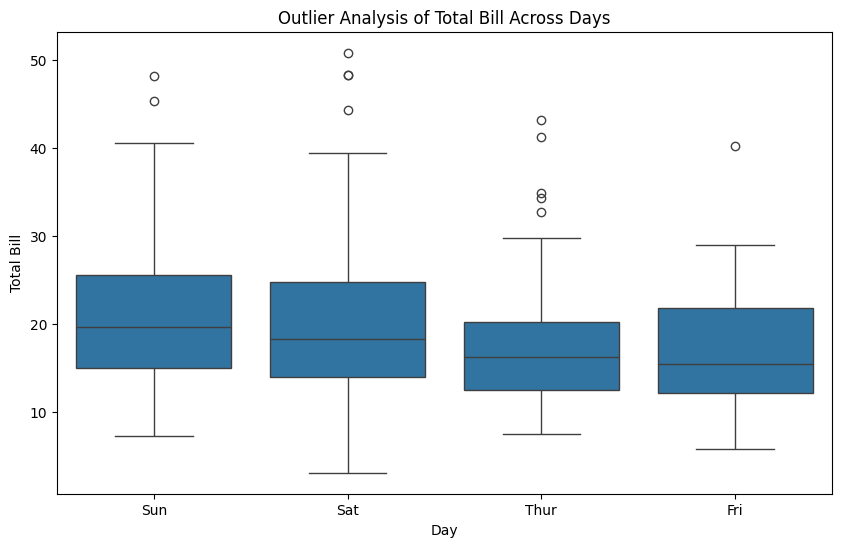

In [17]:
# Cell: Group-wise Outlier Analysis (Optional but Insightful)

try:
    import seaborn as sns

    plt.figure(figsize=(10, 6))
    sns.boxplot(x='day', y='total_bill', data=df)

    plt.title('Outlier Analysis of Total Bill Across Days')
    plt.xlabel('Day')
    plt.ylabel('Total Bill')
    plt.show()

except Exception as e:
    print("Error in grouped boxplot:", str(e))

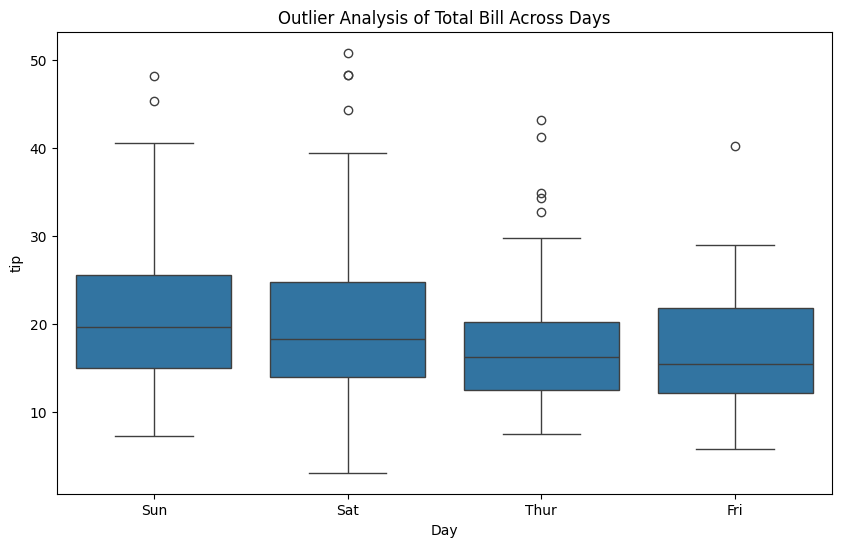

In [19]:
# Cell: Group-wise Outlier Analysis (Optional but Insightful)

try:
    import seaborn as sns

    plt.figure(figsize=(10, 6))
    sns.boxplot(x='day', y='total_bill', data=df)

    plt.title('Outlier Analysis of Total Bill Across Days')
    plt.xlabel('Day')
    plt.ylabel('tip')
    plt.show()

except Exception as e:
    print("Error in grouped boxplot:", str(e))

Task 5: Univariate Analysis

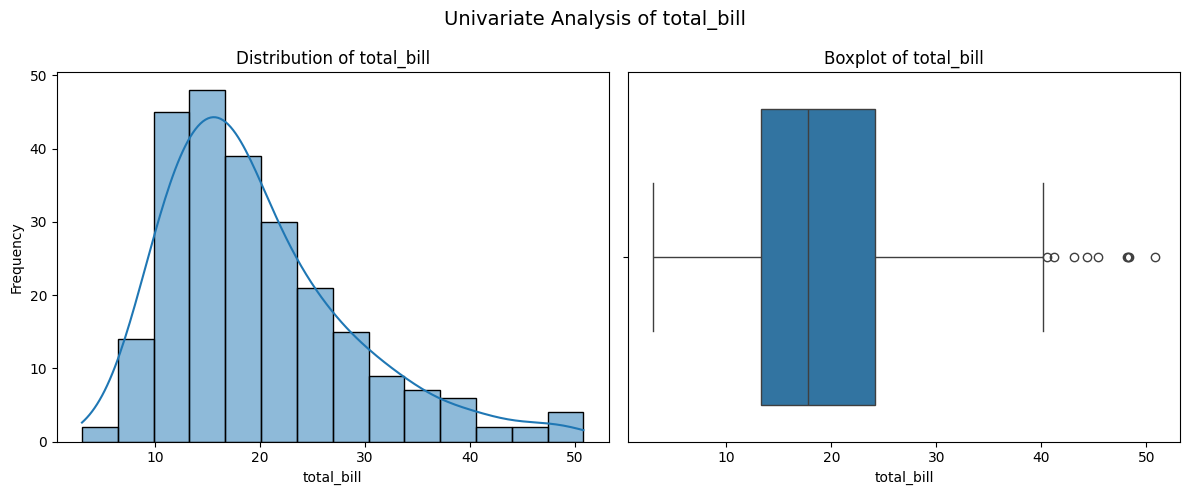

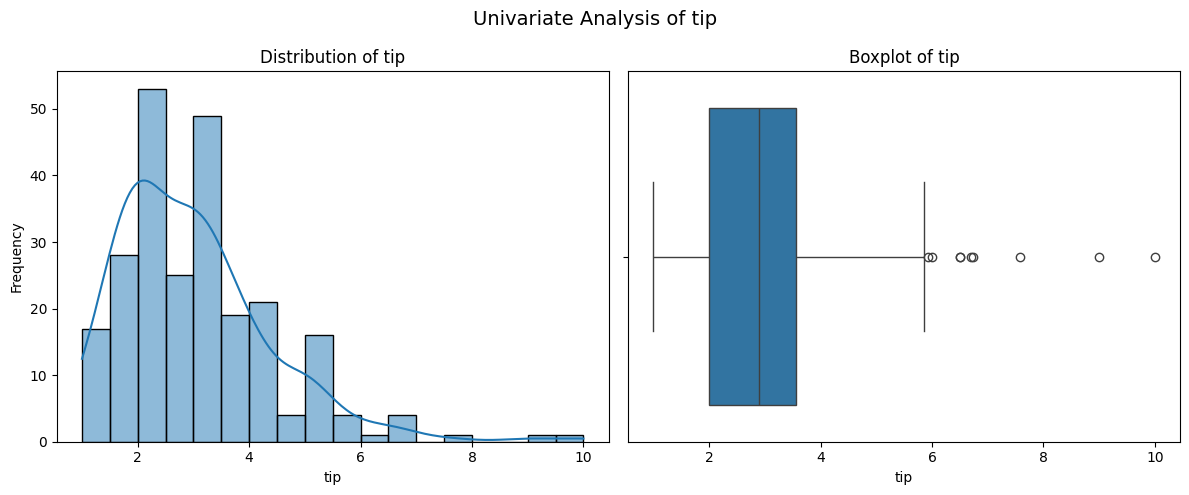

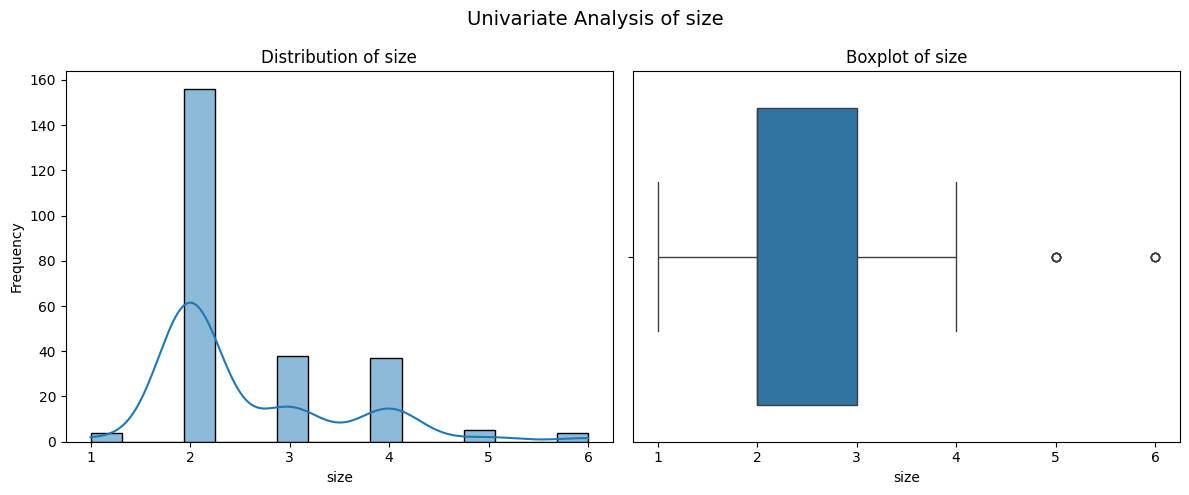

In [20]:
# Cell 1: Univariate Analysis for Numerical Columns

import seaborn as sns

try:
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns

    for col in num_cols:
        plt.figure(figsize=(12, 5))

        # Histogram with KDE
        plt.subplot(1, 2, 1)
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')

        # Boxplot
        plt.subplot(1, 2, 2)
        sns.boxplot(x=df[col])
        plt.title(f'Boxplot of {col}')
        plt.xlabel(col)

        plt.suptitle(f'Univariate Analysis of {col}', fontsize=14)
        plt.tight_layout()
        plt.show()

except Exception as e:
    print("Error in numerical univariate analysis:", str(e))

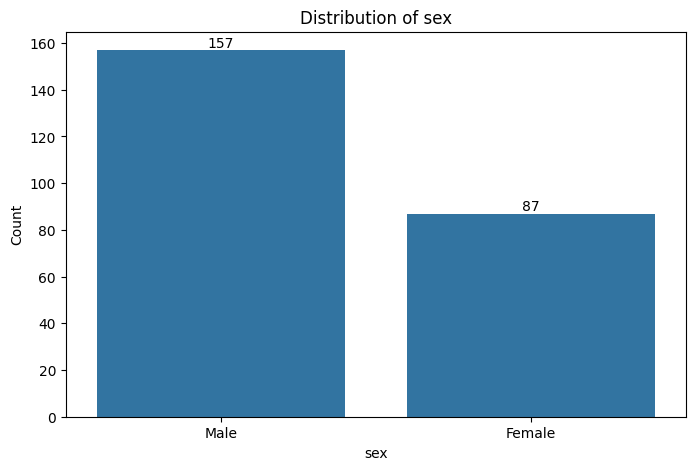

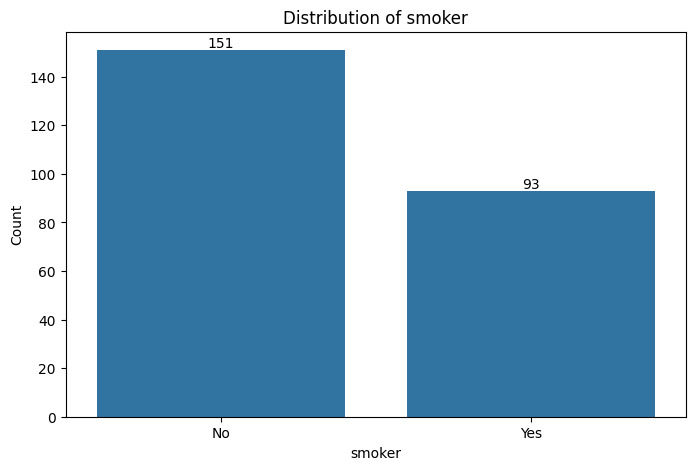

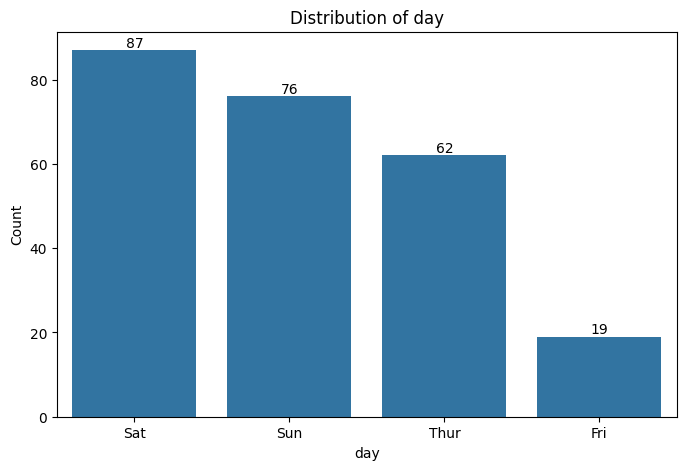

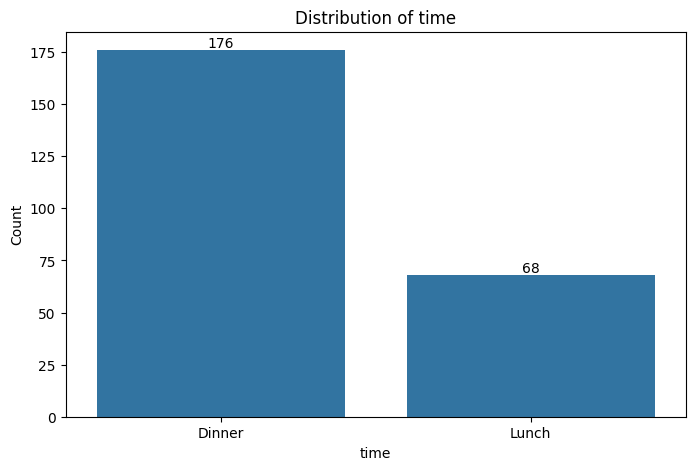

In [21]:
# Cell 2: Univariate Analysis for Categorical Columns

try:
    cat_cols = df.select_dtypes(include=['object']).columns

    for col in cat_cols:
        plt.figure(figsize=(8, 5))

        # Count Plot
        sns.countplot(x=col, data=df, order=df[col].value_counts().index)

        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')

        # Add value labels on bars
        for p in plt.gca().patches:
            plt.gca().annotate(f'{int(p.get_height())}',
                               (p.get_x() + p.get_width() / 2., p.get_height()),
                               ha='center', va='bottom')

        plt.show()

except Exception as e:
    print("Error in categorical univariate analysis:", str(e))

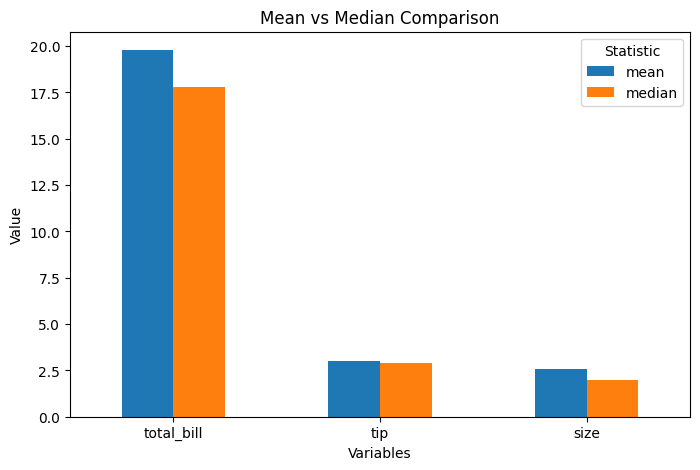

In [22]:
# Cell 3: Summary Statistics (Mean vs Median)

try:
    summary_stats = df[num_cols].agg(['mean', 'median']).T

    summary_stats.plot(kind='bar', figsize=(8, 5))

    plt.title('Mean vs Median Comparison')
    plt.xlabel('Variables')
    plt.ylabel('Value')
    plt.xticks(rotation=0)
    plt.legend(title='Statistic')

    plt.show()

except Exception as e:
    print("Error in summary stats visualization:", str(e))

6. Bivariate Analysis

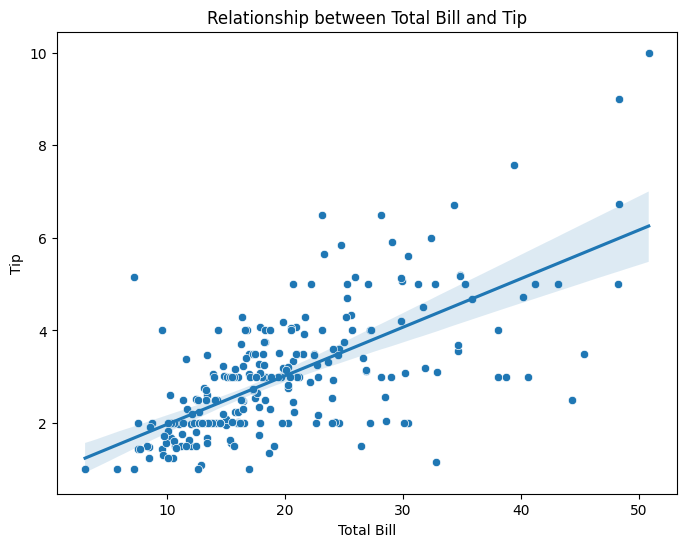

Correlation between Total Bill and Tip: 0.68


In [23]:
# Cell 1: Bivariate Analysis - Tip vs Total Bill

import seaborn as sns

try:
    plt.figure(figsize=(8, 6))

    sns.scatterplot(x='total_bill', y='tip', data=df)
    sns.regplot(x='total_bill', y='tip', data=df, scatter=False)  # trend line

    plt.title('Relationship between Total Bill and Tip')
    plt.xlabel('Total Bill')
    plt.ylabel('Tip')
    plt.show()

    # Correlation
    corr = df['total_bill'].corr(df['tip'])
    print(f"Correlation between Total Bill and Tip: {corr:.2f}")

except Exception as e:
    print("Error in Tip vs Total Bill analysis:", str(e))

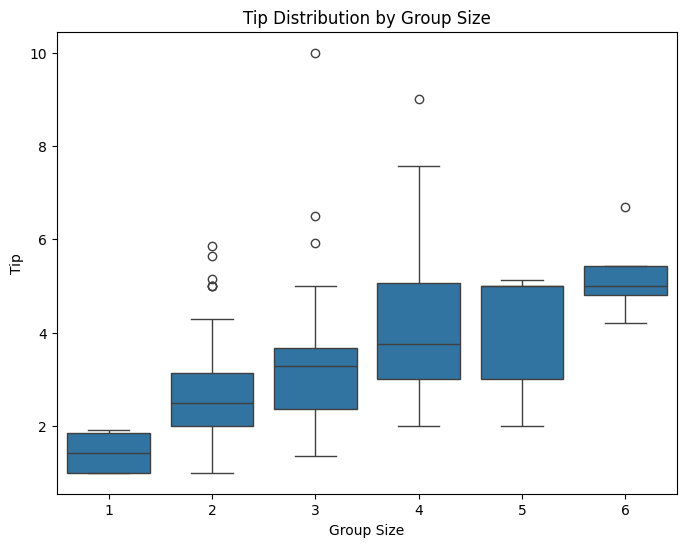

Average Tip by Group Size:
 size
1   1.44
2   2.58
3   3.39
4   4.14
5   4.03
6   5.22
Name: tip, dtype: float64


In [24]:
# Cell 2: Bivariate Analysis - Tip vs Size

try:
    plt.figure(figsize=(8, 6))

    sns.boxplot(x='size', y='tip', data=df)

    plt.title('Tip Distribution by Group Size')
    plt.xlabel('Group Size')
    plt.ylabel('Tip')
    plt.show()

    # Group summary
    size_summary = df.groupby('size')['tip'].mean()
    print("Average Tip by Group Size:\n", size_summary)

except Exception as e:
    print("Error in Tip vs Size analysis:", str(e))

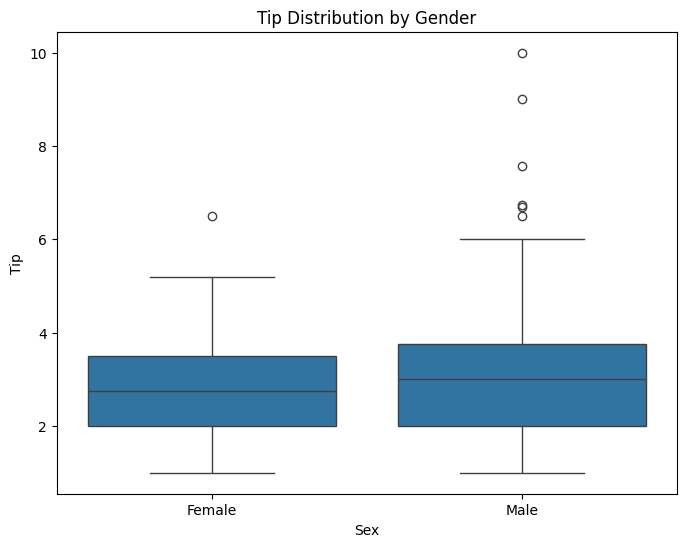

Tip Summary by Sex:
         mean  median
sex                 
Female  2.83    2.75
Male    3.09    3.00


In [25]:
# Cell 3: Bivariate Analysis - Tip vs Sex

try:
    plt.figure(figsize=(8, 6))

    sns.boxplot(x='sex', y='tip', data=df)

    plt.title('Tip Distribution by Gender')
    plt.xlabel('Sex')
    plt.ylabel('Tip')
    plt.show()

    # Summary stats
    sex_summary = df.groupby('sex')['tip'].agg(['mean', 'median'])
    print("Tip Summary by Sex:\n", sex_summary)

except Exception as e:
    print("Error in Tip vs Sex analysis:", str(e))

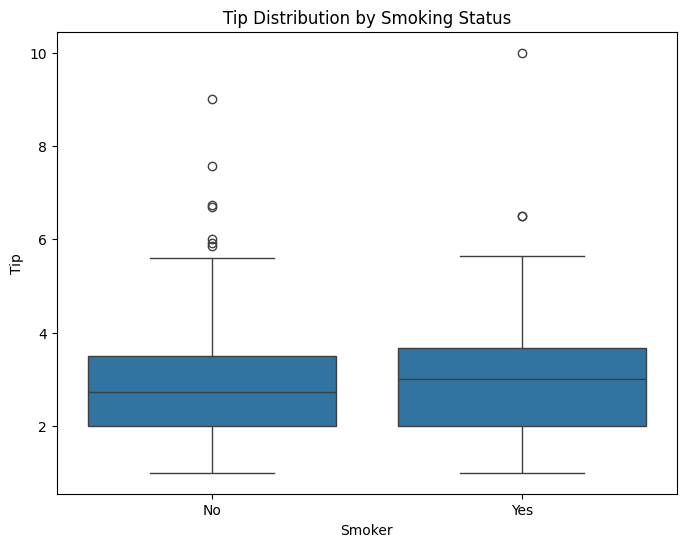

Tip Summary by Smoker Status:
         mean  median
smoker              
No      2.99    2.74
Yes     3.01    3.00


In [26]:
# Cell 4: Bivariate Analysis - Tip vs Smoker

try:
    plt.figure(figsize=(8, 6))

    sns.boxplot(x='smoker', y='tip', data=df)

    plt.title('Tip Distribution by Smoking Status')
    plt.xlabel('Smoker')
    plt.ylabel('Tip')
    plt.show()

    # Summary stats
    smoker_summary = df.groupby('smoker')['tip'].agg(['mean', 'median'])
    print("Tip Summary by Smoker Status:\n", smoker_summary)

except Exception as e:
    print("Error in Tip vs Smoker analysis:", str(e))

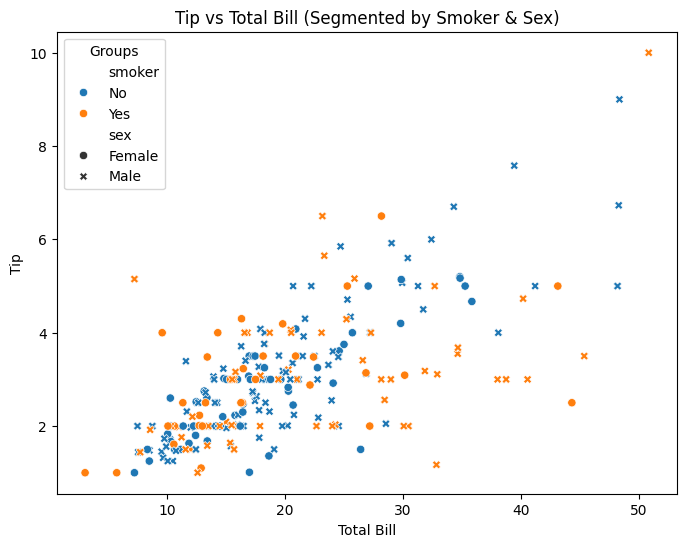

In [28]:
# Cell 5: Multivariate Enhancement (Optional but Powerful)

try:
    plt.figure(figsize=(8, 6))

    sns.scatterplot(x='total_bill', y='tip', hue='smoker', style='sex', data=df)

    plt.title('Tip vs Total Bill (Segmented by Smoker & Sex)')
    plt.xlabel('Total Bill')
    plt.ylabel('Tip')
    plt.legend(title='Groups')
    plt.show()

except Exception as e:
    print("Error in combined analysis:", str(e))